In [1]:
import igraph as ig 
import numpy as np
import matplotlib.pyplot as plt
from sys import stdout

from segregation_model import *
from lorenzo_utils import *

G = load_graph(DATA_DIR+'climate_23.graphml')
attr_map = np.array([1 if v == 'A' else 0 for v in G.vs['group']])
nodes = nodes_all(G)
nodes_satisfaction = np.array([satisfaction(n,G.neighbors(n),G.vs['group']) for n in nodes])

Threshold:  0.5
target simulazione: EI = -0.93    Fraction = 0.965 

Simulation started with: EI = -0.0529    Fraction = 0.5265 

Segregation Model Step 1
Changed 3815 nodes with 3815 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.2098    Fraction = 0.6049 

Segregation Model Step 2
Changed 1204 nodes with 1204 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.245    Fraction = 0.6225 

Segregation Model Step 3
Changed 647 nodes with 647 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.2642    Fraction = 0.6321 

Simulation stopped at satisfaction rate of: 94.25603693181817 %
Threshold:  0.7
target simulazione: EI = -0.93    Fraction = 0.965 

Simulation started with: EI = -0.0663    Fraction = 0.5331 

Segregation Model Step 1
Changed 6093 nodes with 6093 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.2725    Fraction = 0.6362 

Segregation Model Step 2
Changed 3386 nodes with 3386 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.3398    Fraction 

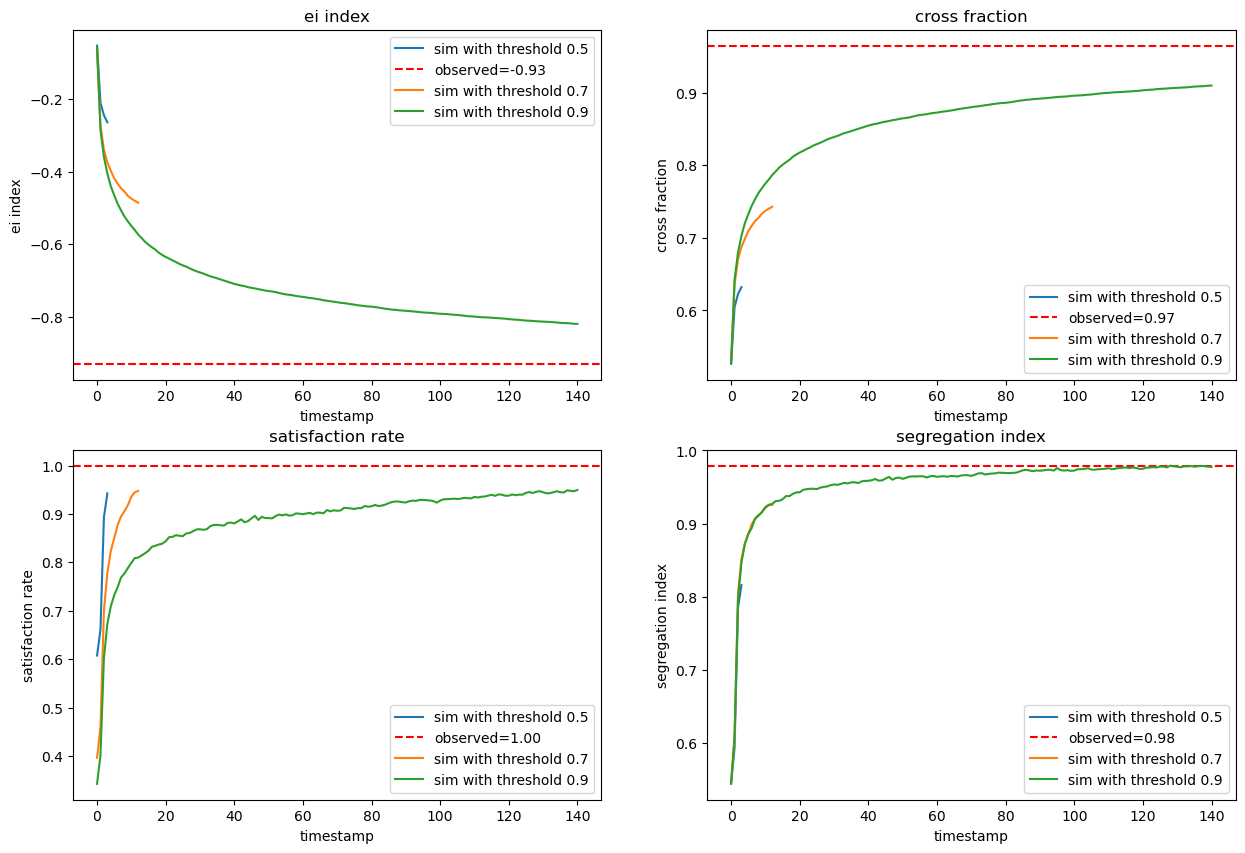

In [4]:
threshold = (0.5, 0.7, 0.9)

fig, axes = plt.subplots(2,2, figsize=(15,10))
for i, treshold in enumerate(threshold):
    print("Threshold: ", treshold)
    ei_obs = ei_index(G, attr_map)
    cross_fraction_obs = 1-cross_type_fraction(G, attr_map)
    satisfaction_rate_obs = nodes_satisfaction[nodes_satisfaction >= treshold].size / nodes.size
    segregation_index_obs = np.mean(nodes_satisfaction)
    ei_index_sim = []
    cross_fraction_sim = []
    satisfaction_rate_sim = []
    segregation_index_sim = []
    print('target simulazione: EI =', round(ei_obs,4), '   Fraction =', round(cross_fraction_obs,4), '\n')
    stdout.flush()
    for G_sim, statistic in segregation_sim(G,treshold):
        ei_index_sim.append(ei_index(G_sim, attr_map))
        cross_fraction_sim.append(1-cross_type_fraction(G_sim, attr_map))
        satisfaction_rate_sim.append(statistic['satisfaction_rate'])
        segregation_index_sim.append(statistic['segregation_index'])
        if statistic['i_step']:
            print(f'Segregation Model Step {statistic['i_step']}')
            print(f'Changed {statistic['nodes_changed_step']} nodes with {statistic['rewires_step']} rewires')
            trys = statistic['nodes_failures_step']+statistic['nodes_changed_step']
            print(f'Failed for', statistic['nodes_failures_step'], 'nodes    success:', 
                statistic['nodes_changed_step']*100/trys if trys else 100, '%')
        print('' if statistic['i_step'] else 'Simulation started with:', 
            'EI =', round(ei_index_sim[-1],4),
            '   Fraction =', round(cross_fraction_sim[-1],4),'\n')
        stdout.flush()

    if not statistic['nodes_changed_step']:
        print('Simulation ended in a stable configuration at step', statistic['i_step'])
        print('Total failures', len(list(filter(lambda x: x>0, statistic['nodes_failures']))))
    else:
        print('Simulation stopped at satisfaction rate of:', statistic['satisfaction_rate']*100, '%')

    

    time_st = range(len(ei_index_sim))
    simulation = [ei_index_sim, cross_fraction_sim, satisfaction_rate_sim, segregation_index_sim]
    observed  = [ei_obs, cross_fraction_obs, satisfaction_rate_obs, segregation_index_obs]
    titles = ['ei index', 'cross fraction', 'satisfaction rate', 'segregation index']

    for ax, sim, obs, title in zip(axes.flat, simulation, observed, titles):
        ax.plot(time_st, sim, label=f'sim with threshold {treshold}')
        ax.set_xlabel('timestamp')
        ax.set_ylabel(title)
        if i == 0: 
            ax.axhline(obs, color='red', linestyle='--', label=f'observed={obs:.2f}')
          
        ax.set_title(title)
        ax.legend()
        

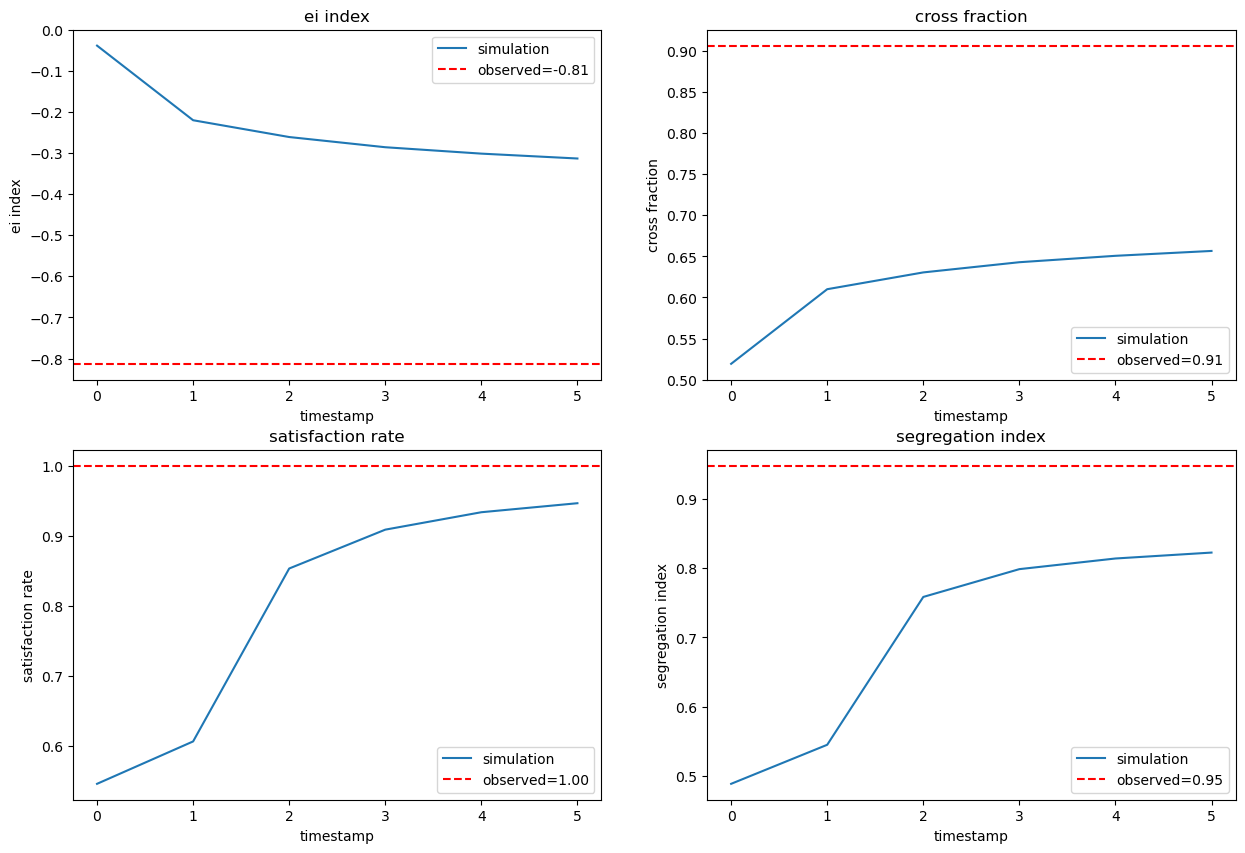

In [3]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

time_st = range(len(ei_index_sim))
simulation = [ei_index_sim, cross_fraction_sim, satisfaction_rate_sim, segregation_index_sim]
observed  = [ei_obs, cross_fraction_obs, satisfaction_rate_obs, segregation_index_obs]
titles = ['ei index', 'cross fraction', 'satisfaction rate', 'segregation index']

for ax, sim, obs, title in zip(axes.flat, simulation, observed, titles):
    ax.plot(time_st, sim, label='simulation')
    ax.set_xlabel('timestamp')
    ax.set_ylabel(title)
    ax.axhline(obs, color='red', linestyle='--', label=f'observed={obs:.2f}')
    ax.set_title(title)
    ax.legend()
    